Датасет успешно загружен.

Первые 5 строк датасета:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Статистическое опис

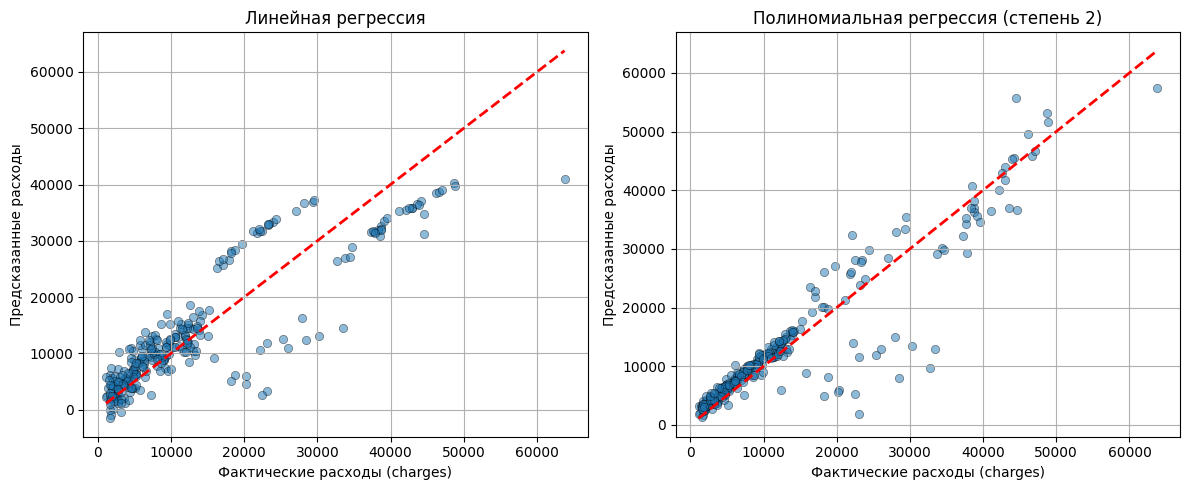

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    data = pd.read_csv('insurance.csv')
    print("Датасет успешно загружен.")
except FileNotFoundError:
    print("Файл 'insurance.csv' не найден. Проверьте путь к файлу.")

print("\nПервые 5 строк датасета:")
print(data.head())

print("\nИнформация о датасете:")
data.info()

print("\nСтатистическое описание числовых признаков:")
print(data.describe())

print("\nПропущенные значения в каждом столбце:")
print(data.isnull().sum())

categorical_features = ['sex', 'smoker', 'region']
numeric_features = ['age', 'bmi', 'children']

target = 'charges'

X = data.drop(target, axis=1)
y = data[target]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]} записей")
print(f"Размер тестовой выборки: {X_test.shape[0]} записей")

linear_model_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_model_pipe.fit(X_train, y_train)

y_pred_linear = linear_model_pipe.predict(X_test)

print("\n--- Линейная регрессия ---")
print(f"MAE (Средняя абсолютная ошибка): {mean_absolute_error(y_test, y_pred_linear):.2f}")
print(f"MSE (Среднеквадратичная ошибка): {mean_squared_error(y_test, y_pred_linear):.2f}")
print(f"RMSE (Корень из среднеквадратичной ошибки): {np.sqrt(mean_squared_error(y_test, y_pred_linear)):.2f}")
print(f"R² (Коэффициент детерминации): {r2_score(y_test, y_pred_linear):.4f}")

poly_model_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', LinearRegression())
])

poly_model_pipe.fit(X_train, y_train)

y_pred_poly = poly_model_pipe.predict(X_test)

print("\n--- Полиномиальная регрессия (степень 2) ---")
print(f"MAE (Средняя абсолютная ошибка): {mean_absolute_error(y_test, y_pred_poly):.2f}")
print(f"MSE (Среднеквадратичная ошибка): {mean_squared_error(y_test, y_pred_poly):.2f}")
print(f"RMSE (Корень из среднеквадратичной ошибки): {np.sqrt(mean_squared_error(y_test, y_pred_poly)):.2f}")
print(f"R² (Коэффициент детерминации): {r2_score(y_test, y_pred_poly):.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_linear, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Фактические расходы (charges)')
plt.ylabel('Предсказанные расходы')
plt.title('Линейная регрессия')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_poly, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Фактические расходы (charges)')
plt.ylabel('Предсказанные расходы')
plt.title('Полиномиальная регрессия (степень 2)')
plt.grid(True)

plt.tight_layout()
plt.show()
